In [66]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# append my path
project_root = os.path.abspath('..')
sys.path.append(project_root)

from utils.utils import *

%pip install oasis-deconv
from oasis.functions import deconvolve

Note: you may need to restart the kernel to use updated packages.


In [67]:
data = load_data()
print_info(data)

matched cells: 47
templates: ['locally_sparse_noise', 'natural_scenes']

session A (three_session_A)
  t: (115471,), dff: (47, 115471), roi_masks: (47, 512, 512)
  stim 'drifting_gratings': (628, 5) cols=['temporal_frequency', 'orientation', 'blank_sweep', 'start', 'end']

session B (three_session_B)
  t: (113850,), dff: (47, 113850), roi_masks: (47, 512, 512)
  stim 'natural_scenes': (5950, 3) cols=['frame', 'start', 'end']
  stim 'static_gratings': (6000, 5) cols=['orientation', 'spatial_frequency', 'phase', 'start', 'end']

session C (three_session_C)
  t: (105738,), dff: (47, 105738), roi_masks: (47, 512, 512)
  stim 'locally_sparse_noise': (8880, 3) cols=['frame', 'start', 'end']


## Data preprocessing

In [68]:
### Spike transformation function definition
def infer_spikes_oasis(session, fs):
    dff = session["dff"]
    n_cells, n_time = dff.shape
    spikes = np.zeros_like(dff)
    calcium = np.zeros_like(dff)
    for i in range(n_cells):
        c, s, b, g, lam = deconvolve(dff[i], penalty = 1) # tau_d=0.1, framerate=fs)
        spikes[i] = s
        calcium[i] = c
    return spikes, calcium

### Data processing
for name, session in data["sessions"].items():
    fs = 1.0 / np.median(np.diff(session["t"]))
    spikes, calcium = infer_spikes_oasis(session, fs)
    session["spikes"] = spikes
    session["calcium_fit"] = calcium

In [69]:
save_data(data, "data_with_spikes")

In [70]:
data = load_saved_data("data_with_spikes")

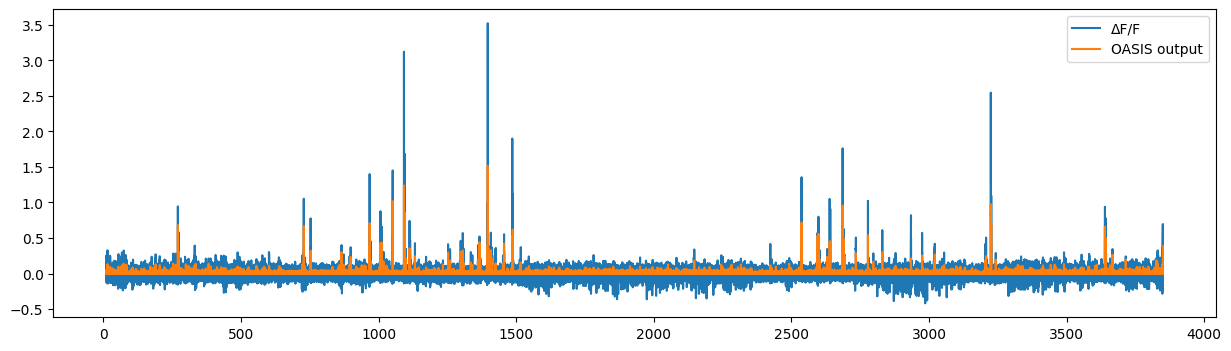

In [71]:
plt.figure(figsize=(15, 4))

plt.plot(session["t"], session["dff"][0], label="ΔF/F")
plt.plot(session["t"], session["spikes"][0], label="OASIS output")

plt.legend()

In [72]:
def preprocess_running_speed(
    data: dict,
    high: float = 3.0,
    order: int = 3,
    clip_speed: bool = True,
    running_threshold: float = 2.0,
    ) -> dict:

    for name, session in data["sessions"].items():
        speed = np.asarray(session["running_speed"][0], dtype=float)
        t = np.asarray(session["running_speed"][1], dtype=float)
        dt = np.median(np.diff(t))

        fs = 1.0 / dt
        nyquist = 0.5 * fs
        if not (0 < high < nyquist):
            raise ValueError(f"{name}: high must be between 0 and {nyquist:.3f} Hz, got {high}")

        valid = np.isfinite(speed)

        # We have nans at beginning and end of the speed trace,
        # so we need to interpolate to fill them in before filtering.
        speed_interp = np.interp(
            np.arange(speed.size),
            np.flatnonzero(valid),
            speed[valid],
        )

        b, a = signal.butter(order, high, btype="low", fs=fs)
        speed_filtered = signal.filtfilt(b, a, speed_interp)

        # clip running speed at 0
        if clip_speed:
            speed_filtered = np.clip(speed_filtered, 0, None)

        # Separate filtered speed into two kinematic phases: still (0) vs running (1).
        phases = np.full(speed_filtered.shape, -1, dtype=int)
        phases[speed_filtered <= running_threshold] = 0
        phases[speed_filtered > running_threshold] = 1

        # Restore missing values in filtered signal while keeping phase=-1 for invalid points.
        speed_filtered[~valid] = np.nan
        phases[~valid] = -1
        session["running_speed_filtered"] = np.vstack([speed_filtered, t])
        session["running_speed_phase"] = phases

    return data

In [73]:
data = preprocess_running_speed(data, high=5, order=3, clip_speed=True, running_threshold=5.0)

In [74]:
data["sessions"]["B"]["running_speed_phase"]

array([-1, -1, -1, ..., -1, -1, -1], shape=(113850,))

In [75]:
def plot_running_speed(data, session="B", t=(0, 100)):
    """Plot raw and filtered running speed with phase background blocks."""
    session_data = data["sessions"][session]

    speed_raw, time_raw = (np.asarray(a, dtype=float) for a in session_data["running_speed"])
    speed_filt, time_filt = (np.asarray(a, dtype=float) for a in session_data["running_speed_filtered"])

    fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    axs[0].plot(time_raw, speed_raw, color="0.2", lw=0.8)
    axs[0].set(xlim=t, title="Original Running Speed", ylabel="Speed (cm/s)")

    axs[1].plot(time_filt, speed_filt, color="0.2", lw=0.8)
    axs[1].set(xlim=t, title="Filtered Running Speed", ylabel="Speed (cm/s)", xlabel="Time (s)")

    # Shade contiguous phase blocks on both subplots.

    phase = np.asarray(session_data["running_speed_phase"], dtype=int)
    
    phase_names = {-1: "Invalid", 0: "Still", 1: "Running"}
    phase_colors = {-1: "0.8", 0: "tab:blue", 1: "tab:red"}

    change_points = np.flatnonzero(np.diff(phase)) + 1 # get the indices where the phase changes
    block_starts = np.concatenate(([0], change_points))
    block_ends = np.concatenate((change_points, [phase.size]))

    seen_labels = set()
    for start, end in zip(block_starts, block_ends):
        p = phase[start]
        label = phase_names.get(p, f"Phase {p}") if p not in seen_labels else None
        seen_labels.add(p)
        for ax in axs:
            ax.axvspan(
                time_filt[start], time_filt[end - 1],
                color=phase_colors.get(p, "0.5"), alpha=0.2, label=label,
            )

    axs[1].legend(loc="upper right")
    fig.tight_layout()
    return fig, axs

In [76]:
# safe data 
save_data(data, "data_with_spikes_and_speed")

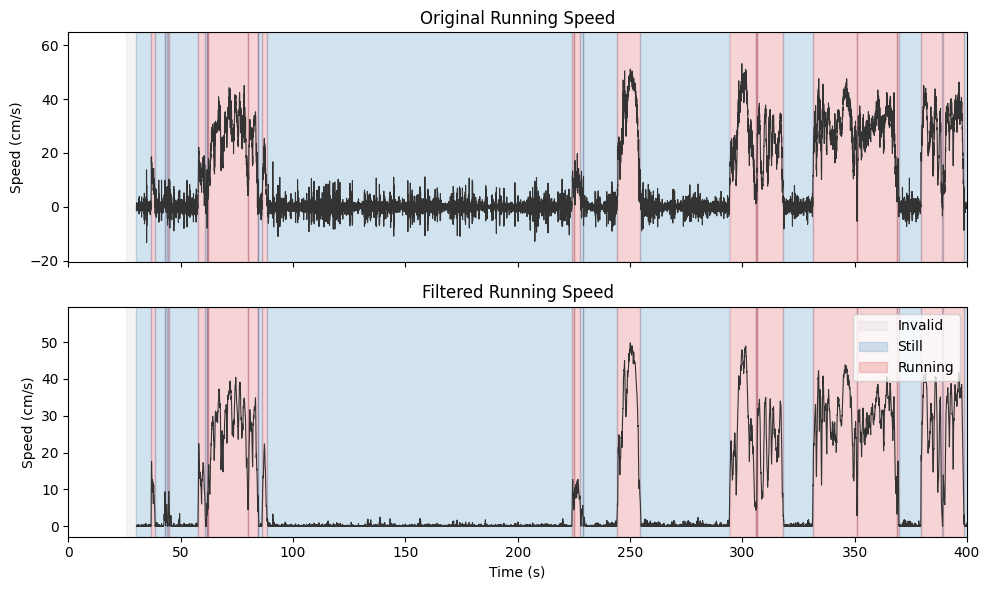

In [77]:
fig, axs = plot_running_speed(data, session="B", t=(0, 400))
plt.show()

## Extract the running speed across different stimulus

In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

STIMULUS_SESSION_MAP = {
    "drifting_gratings":    "A",
    "static_gratings":      "B",
    "natural_scenes":       "B",
    "locally_sparse_noise": "C",
}

def get_running_speed_by_stimulus(data, stimulus_session_map=STIMULUS_SESSION_MAP, filtered=True):
    """
    Extract running speed values during each stimulus's presentation trials.
    Uses the filtered (smoothed, clipped) speed trace by default.
    """
    stimulus_speed = {}

    for stim_name, session in stimulus_session_map.items():
        s = data["sessions"][session]
        key = "running_speed_filtered" if filtered else "running_speed"
        speed = s[key][0]
        stim_table = s["stim_tables"][stim_name]

        starts = stim_table["start"].astype(int).values
        ends = stim_table["end"].astype(int).values

        speed_values = [speed[start:end + 1] for start, end in zip(starts, ends)]
        stimulus_speed[stim_name] = np.concatenate(speed_values) if speed_values else np.array([])

    return stimulus_speed


def plot_speed_by_stimulus(stimulus_speed, ax=None):
    """
    Plot running speed distributions across the four stimulus types as boxplots,
    with mean values shown as markers and text labels.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 4))

    rows = []
    for stim_name, speeds in stimulus_speed.items():
        for v in speeds:
            rows.append({"stimulus": stim_name, "speed": v})
    df_long = pd.DataFrame(rows)

    sns.boxplot(data=df_long, x="stimulus", y="speed", ax=ax,
                showfliers=False, width=0.5, palette="Set2",
                showmeans=True,
                meanprops={"marker": "D", "markerfacecolor": "white",
                           "markeredgecolor": "black", "markersize": 7})

    # Annotate each box with its mean value as text
    stim_order = list(stimulus_speed.keys())
    for i, stim_name in enumerate(stim_order):
        mean_val = np.mean(stimulus_speed[stim_name])
        ax.text(i, mean_val, f"{mean_val:.2f}", ha="center", va="bottom",
                fontsize=9, fontweight="bold", color="black")

    ax.set_xlabel("stimulus")
    ax.set_ylabel("running speed (cm/s)")
    ax.set_title("Running speed across stimulus types")
    plt.setp(ax.get_xticklabels(), rotation=15, ha="right")

    return ax

## Compare the running speed across different stimulus

/var/folders/42/yzjg5hd11vv65hsck7wh0lb00000gn/T/ipykernel_10599/3318748824.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_long, x="stimulus", y="speed", ax=ax,


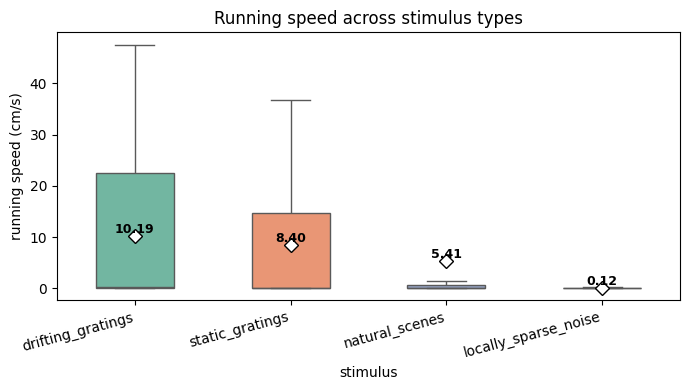

In [ ]:

data = preprocess_running_speed(data)

stimulus_speed = get_running_speed_by_stimulus(data, filtered=True)

fig, ax = plt.subplots(figsize=(7, 4))
plot_speed_by_stimulus(stimulus_speed, ax=ax)
plt.tight_layout()
plt.show()

## Visualize natural scence

In [41]:
len(data["templates"]["natural_scenes"])


118

In [46]:
def show_all_natural_scenes(data, ncols=12):
    '''this function could show all the natural stimulation
    118 in total'''
    tmpl = data["templates"]["natural_scenes"]
    n = tmpl.shape[0]                          # Total 118 frame
    nrows = int(np.ceil(n / ncols))           

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(ncols * 1.5, nrows * 1.5),   
        constrained_layout=True,
    )
    axes = axes.flat                           

    for i, ax in enumerate(axes):
        if i < n:
            ax.imshow(tmpl[i], cmap="gray")
            ax.set_title(str(i), fontsize=6)   
        ax.axis("off")                         
    # return fig

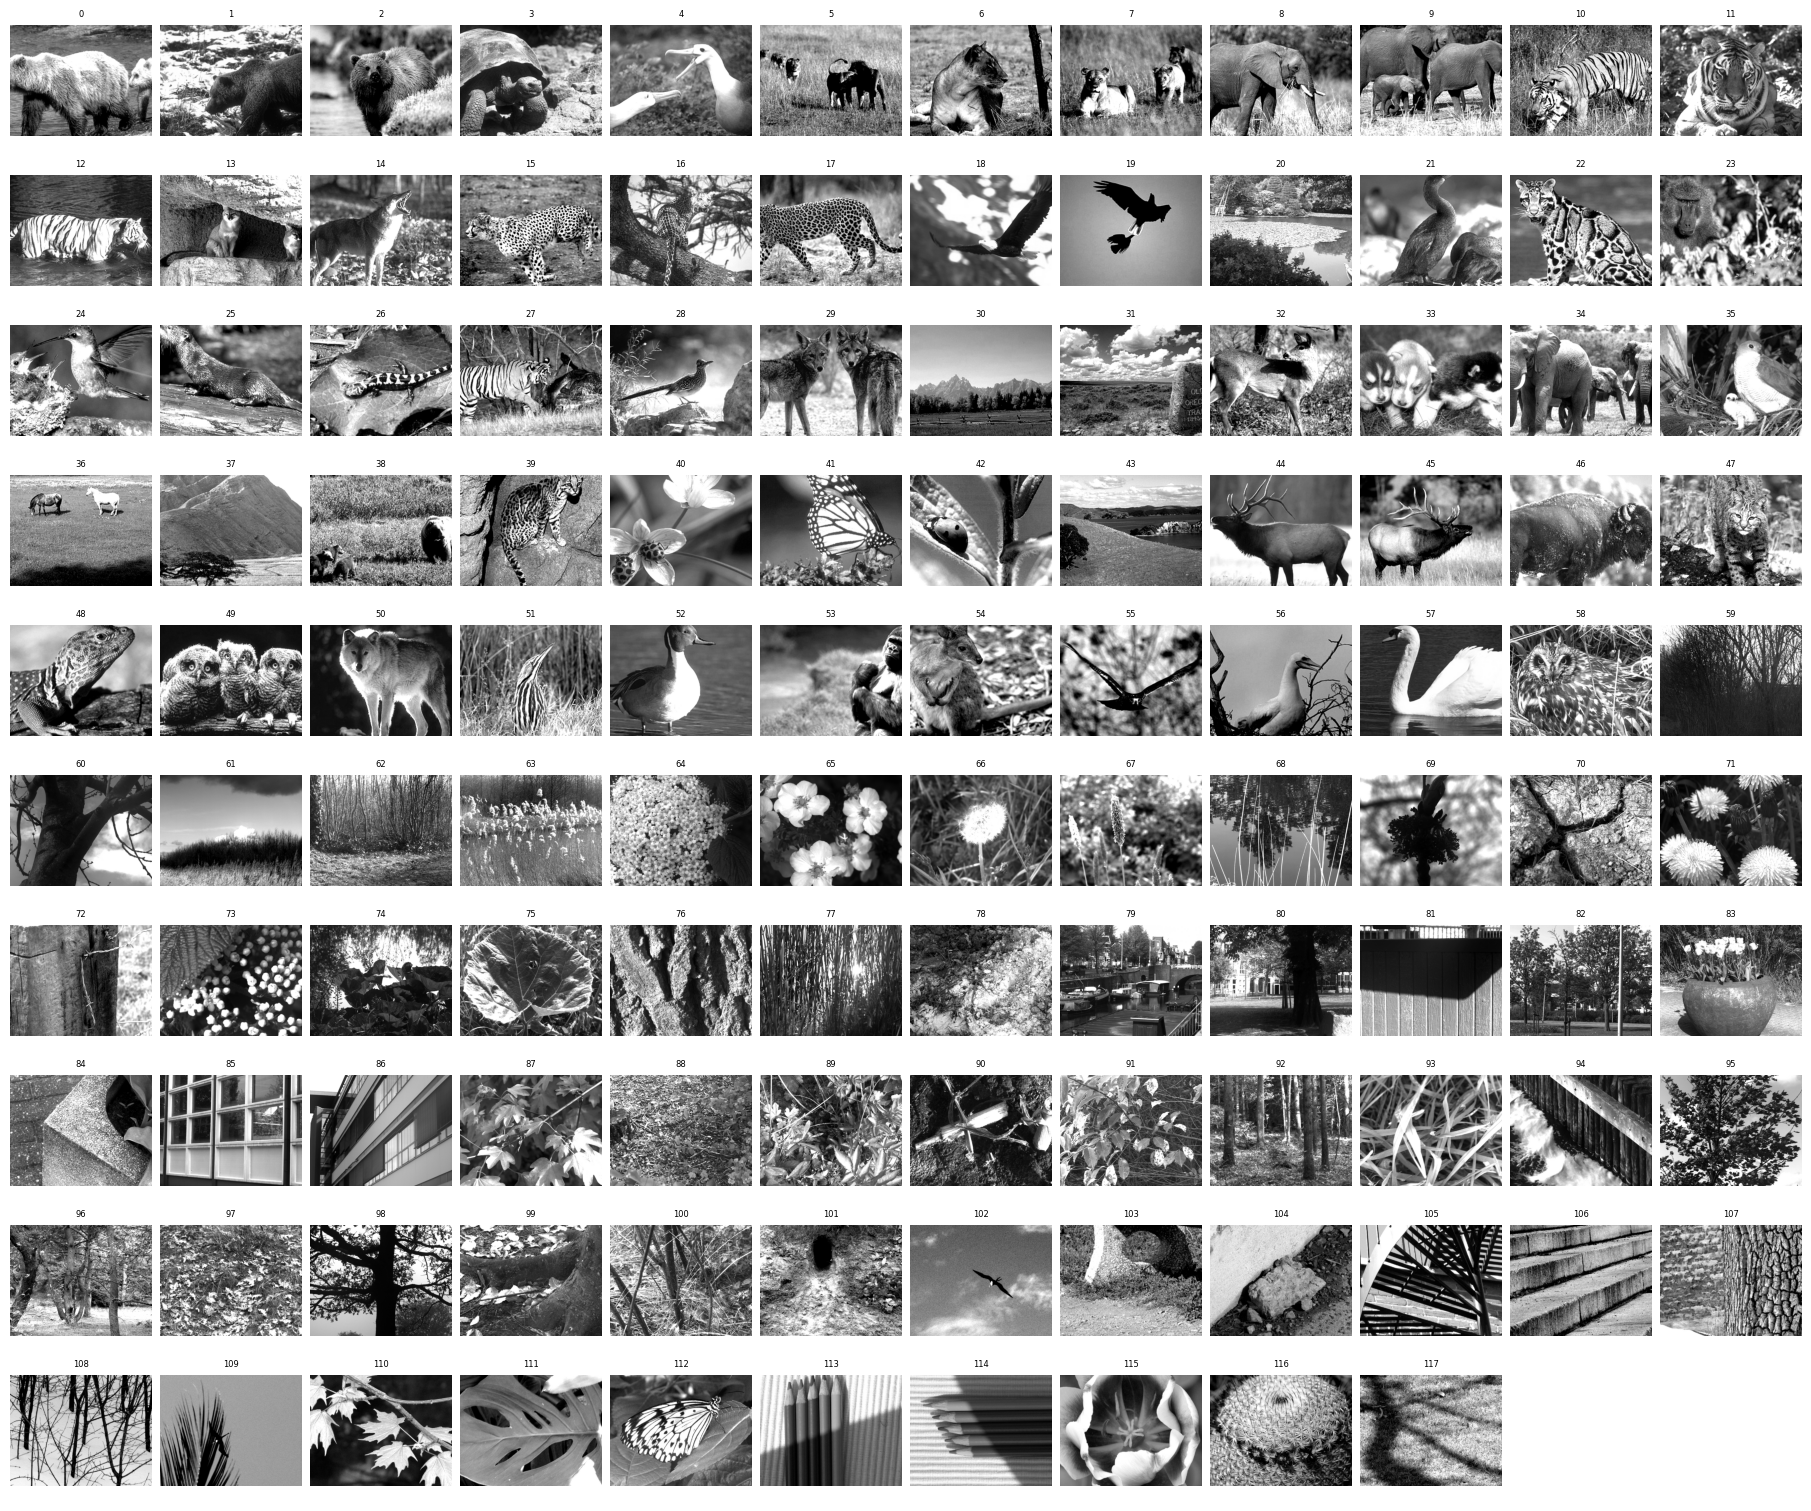

In [47]:
show_all_natural_scenes(data)


## Check which picture show at which trial

In [ ]:
# 1. check the shape and type of the templates
print("=== natural_scenes template ===")
print("type:", type(data["templates"]["natural_scenes"]))
print("shape:", data["templates"]["natural_scenes"].shape)
print("dtype:", data["templates"]["natural_scenes"].dtype)
print("min/max pixel values:", data["templates"]["natural_scenes"].min(), 
      data["templates"]["natural_scenes"].max())

# 2. check stim_table structure
print("\n=== natural_scenes stim_table ===")
print(data["sessions"]["B"]["stim_tables"]["natural_scenes"].head())
print("\nUnique frame values:", 
      sorted(data["sessions"]["B"]["stim_tables"]["natural_scenes"]["frame"].unique()))
print("Number of unique frames:", 
      data["sessions"]["B"]["stim_tables"]["natural_scenes"]["frame"].nunique())

=== natural_scenes template ===
type: <class 'numpy.ndarray'>
shape: (118, 918, 1174)
dtype: uint8
min/max pixel values: 0 255

=== natural_scenes stim_table ===
   frame  start    end
0     35  16096  16103
1     49  16104  16111
2    107  16111  16118
3     53  16119  16126
4    110  16126  16133

Unique frame values: [np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), n

In [99]:
aversive_frames = [
    0, 1, 2,      # bears
    4,            # Bird
    6, 7,         # lions
    8, 9,         # elephant       
    10, 11, 12,   # tigers close-up
    13, 14,       # coyote howling
    15, 16,       # cheetah
    17,           # leopard
    18,           # eagle
    19,           # birds fighting
    21,           # bird
    22,           # leopard/jaguar close-up
    23,           # monkey
    25,           # Otter
    27,           # tiger
    28,           # bird
    29,           # coyotes
    34,           # elephants
    35,           # bird
    39,           # leopard camouflaged
    47,           # bobcat
    49,           # bird
    50,           # wolf/coyote
    51,52,        # bird
    55,56,        # hawk flying
    58,           # owl
    102,          # bird
]

frame_to_category = {i: "aversive" for i in aversive_frames}
for i in range(118):
    if i not in frame_to_category:
        frame_to_category[i] = "neutral"

In [100]:
def get_speed_per_trial(data, session, stim_name, frame_to_category, filtered=True):
    """
    For each stimulus presentation trial, extract the mean running speed
    during that trial, and tag it with its frame number and category.

    Returns
    -------
    pd.DataFrame with columns: frame, category, mean_speed, start, end
    """
    s = data["sessions"][session]
    key = "running_speed_filtered" if filtered else "running_speed"
    speed = s[key][0]
    stim_table = s["stim_tables"][stim_name].copy()

    # Exclude blank sweeps (frame == -1, no image shown)
    stim_table = stim_table[stim_table["frame"] != -1].reset_index(drop=True)

    mean_speeds = []
    for _, row in stim_table.iterrows():
        start, end = int(row["start"]), int(row["end"])
        trial_speed = speed[start:end + 1]
        mean_speeds.append(np.nanmean(trial_speed))

    stim_table["mean_speed"] = mean_speeds
    stim_table["category"] = stim_table["frame"].map(frame_to_category)

    return stim_table

In [101]:
trial_df = get_speed_per_trial(data, session="B", stim_name="natural_scenes",
                                 frame_to_category=frame_to_category)

print(trial_df.head())
#    frame  start    end  mean_speed  category
# 0     35  16096  16103        3.21   neutral
# 1     49  16104  16111        8.55   aversive
# ...

   frame  start    end  mean_speed  category
0     35  16096  16103    0.133995  aversive
1     49  16104  16111    0.103649  aversive
2    107  16111  16118    0.052961   neutral
3     53  16119  16126    0.018418   neutral
4    110  16126  16133    0.000000   neutral


/var/folders/42/yzjg5hd11vv65hsck7wh0lb00000gn/T/ipykernel_10599/1968399236.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=trial_df, x="category", y="mean_speed", ax=ax,


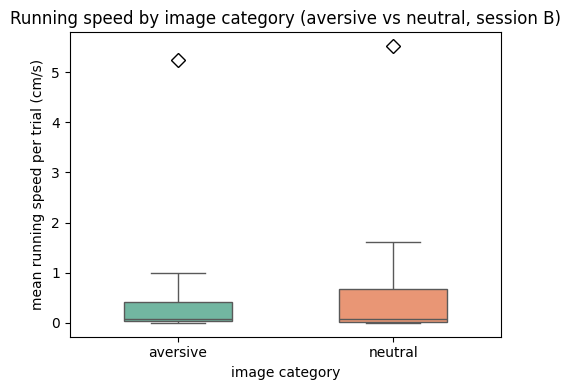

In [121]:
def plot_speed_by_category(trial_df, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4))

    sns.boxplot(data=trial_df, x="category", y="mean_speed", ax=ax,
                showfliers=False, width=0.5, palette="Set2",
                showmeans=True,
                meanprops={"marker": "D", "markerfacecolor": "white",
                           "markeredgecolor": "black", "markersize": 7})

    ax.set_xlabel("image category")
    ax.set_ylabel("mean running speed per trial (cm/s)")
    ax.set_title("Running speed by image category (aversive vs neutral, session B)")

    return ax

plot_speed_by_category(trial_df)
plt.tight_layout()
plt.show()

In [103]:
print(trial_df.groupby("category")["mean_speed"].describe())

           count      mean        std  min       25%       50%       75%  \
category                                                                   
aversive  1850.0  5.241822  10.914557  0.0  0.028143  0.075527  0.420155   
neutral   4050.0  5.518583  11.317725  0.0  0.026472  0.078405  0.680377   

                max  
category             
aversive  54.374424  
neutral   53.367325  


## Conclusion for running speed differentiation


## Spike count comparison across different categories (Aversive vs Neutral)

In [112]:
def get_neural_activity_per_trial(data, session, stim_name, frame_to_category):
    """
    For each stimulus presentation trial, extract the total (summed) spike activity
    during that trial, and tag it with its frame number and category.

    Returns
    -------
    pd.DataFrame with columns: frame, category, sum_spikes, start, end
    """
    s = data["sessions"][session]
    spikes = s["spikes"]  # shape (n_cells, n_timepoints)
    stim_table = s["stim_tables"][stim_name].copy()

    # Exclude blank sweeps (frame == -1, no image shown)
    stim_table = stim_table[stim_table["frame"] != -1].reset_index(drop=True)

    sum_spikes = []
    for _, row in stim_table.iterrows():
        start, end = int(row["start"]), int(row["end"])
        trial_spikes = spikes[:, start:end + 1]
        sum_spikes.append(np.nansum(trial_spikes))

    stim_table["sum_spikes"] = sum_spikes
    stim_table["category"] = stim_table["frame"].map(frame_to_category)

    return stim_table

           count      mean       std       min       25%       50%       75%  \
category                                                                       
aversive  1850.0  1.282755  1.239957  0.000000  0.386504  0.891998  1.760151   
neutral   4050.0  1.190992  1.206044  0.003033  0.337542  0.788963  1.645466   

               max  
category            
aversive  8.176607  
neutral   9.663793  


/var/folders/42/yzjg5hd11vv65hsck7wh0lb00000gn/T/ipykernel_10599/2444613100.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=neural_df, x="category", y="sum_spikes", ax=ax,


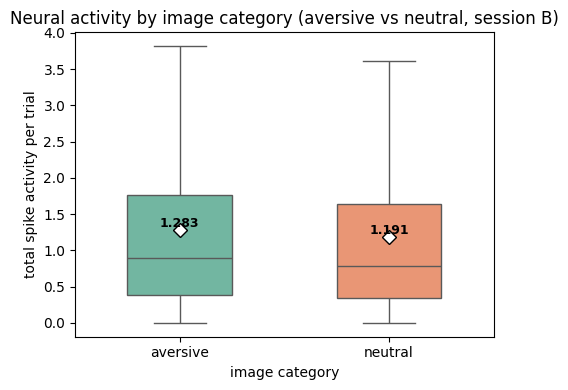

In [120]:
neural_df = get_neural_activity_per_trial(data, session="B", stim_name="natural_scenes",
                                            frame_to_category=frame_to_category)

print(neural_df.groupby("category")["sum_spikes"].describe())

fig, ax = plt.subplots(figsize=(5, 4))
sns.boxplot(data=neural_df, x="category", y="sum_spikes", ax=ax,
            showfliers=False, width=0.5, palette="Set2",
            showmeans=True,
            meanprops={"marker": "D", "markerfacecolor": "white",
                       "markeredgecolor": "black", "markersize": 7})

# Annotate each box with its mean value as text
categories = neural_df["category"].unique()
for i, cat in enumerate(categories):
    mean_val = neural_df[neural_df["category"] == cat]["sum_spikes"].mean()
    ax.text(i, mean_val, f"{mean_val:.3f}", ha="center", va="bottom",
            fontsize=9, fontweight="bold", color="black")

ax.set_xlabel("image category")
ax.set_ylabel("total spike activity per trial")
ax.set_title("Neural activity by image category (aversive vs neutral, session B)")
plt.tight_layout()
plt.show()

In [109]:
print("spikes overall comparison:")
print(f"  min: {data['sessions']['B']['spikes'].min():.6f}")
print(f"  max: {data['sessions']['B']['spikes'].max():.6f}")
print(f"  mean: {data['sessions']['B']['spikes'].mean():.6f}")
print(f"  % the propotion close to 0: {(data['sessions']['B']['spikes'] < 1e-6).mean() * 100:.1f}%")

spikes overall comparison:
  min: -0.000000
  max: 2.611384
  mean: 0.002700
  % the propotion close to 0: 94.4%


## Comparison across different stimulus

In [117]:
STIMULUS_SESSION_MAP = {
    "drifting_gratings":    "A",
    "static_gratings":      "B",
    "natural_scenes":       "B",
    "locally_sparse_noise": "C",
}

def get_neural_activity_by_stimulus(data, stimulus_session_map=STIMULUS_SESSION_MAP):
    """
    Extract total (summed) spike activity during each stimulus's presentation trials,
    across all four stimulus types (spanning sessions A, B, C).

    Returns
    -------
    dict: {stimulus_name: np.ndarray of per-trial summed spike values}
    """
    stimulus_activity = {}

    for stim_name, session in stimulus_session_map.items():
        s = data["sessions"][session]
        spikes = s["spikes"]
        stim_table = s["stim_tables"][stim_name]

        starts = stim_table["start"].astype(int).values
        ends = stim_table["end"].astype(int).values

        trial_sums = [np.nansum(spikes[:, start:end + 1]) for start, end in zip(starts, ends)]
        stimulus_activity[stim_name] = np.array(trial_sums)

    return stimulus_activity

def plot_activity_by_stimulus(stimulus_activity, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 4))

    rows = []
    for stim_name, values in stimulus_activity.items():
        for v in values:
            rows.append({"stimulus": stim_name, "sum_spikes": v})
    df_long = pd.DataFrame(rows)

    sns.boxplot(data=df_long, x="stimulus", y="sum_spikes", ax=ax,
                showfliers=False, width=0.5, palette="Set2",
                showmeans=True,
                meanprops={"marker": "D", "markerfacecolor": "white",
                           "markeredgecolor": "black", "markersize": 7})

    stim_order = list(stimulus_activity.keys())
    for i, stim_name in enumerate(stim_order):
        mean_val = np.mean(stimulus_activity[stim_name])
        ax.text(i, mean_val, f"{mean_val:.3f}", ha="center", va="bottom",
                fontsize=9, fontweight="bold", color="black")

    ax.set_xlabel("stimulus")
    ax.set_ylabel("total population spike activity per trial")
    ax.set_title("Neural activity across stimulus types")
    plt.setp(ax.get_xticklabels(), rotation=15, ha="right")

    return ax

/var/folders/42/yzjg5hd11vv65hsck7wh0lb00000gn/T/ipykernel_10599/931326212.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_long, x="stimulus", y="sum_spikes", ax=ax,


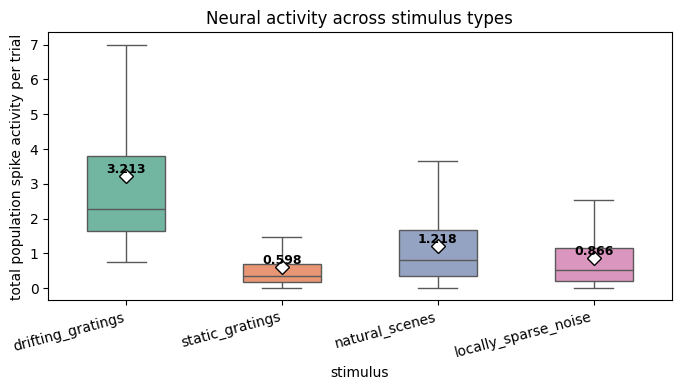

In [118]:
stimulus_activity = get_neural_activity_by_stimulus(data)

fig, ax = plt.subplots(figsize=(7, 4))
plot_activity_by_stimulus(stimulus_activity, ax=ax)
plt.tight_layout()
plt.show()

In [122]:
def plot_spike_raster(data, session, ax=None, threshold=0.05, xlim=None):
    """
    Plot a raster plot of inferred spike activity across all neurons in a session.
    Each row is a neuron; each vertical tick marks a time point where spike
    activity exceeds the threshold (since OASIS output is continuous, not binary).

    Parameters
    ----------
    threshold : float
        Minimum spike value to count as a "spike event" for raster display.
        Adjust based on your data's typical spike amplitude range.
    xlim : tuple, optional
        (start_time, end_time) in seconds to zoom into a specific window.
    """
    s = data["sessions"][session]
    spikes = s["spikes"]  # shape (n_cells, n_timepoints)
    t = s["t"]
    n_cells = spikes.shape[0]

    if ax is None:
        _, ax = plt.subplots(figsize=(12, 6))

    for cell_idx in range(n_cells):
        spike_times = t[spikes[cell_idx] > threshold]
        ax.vlines(spike_times, cell_idx + 0.5, cell_idx + 1.5, color="black", linewidth=0.5)

    ax.set_xlabel("time (s)")
    ax.set_ylabel("neuron #")
    ax.set_ylim(0.5, n_cells + 0.5)
    ax.set_title(f"session {session}: spike raster ({n_cells} neurons)")

    if xlim is not None:
        ax.set_xlim(xlim)

    return ax

In [139]:
for session in ["A", "B", "C"]:
    t = data["sessions"][session]["t"]
    print(f"Session {session}: {t[0]:.1f}s ~ {t[-1]:.1f}s (overall length {t[-1] - t[0]:.1f} 秒)")

Session A: 9.7s ~ 3849.6s (overall length 3839.9 秒)
Session B: 25.4s ~ 3811.3s (overall length 3785.9 秒)
Session C: 7.7s ~ 3523.6s (overall length 3515.8 秒)


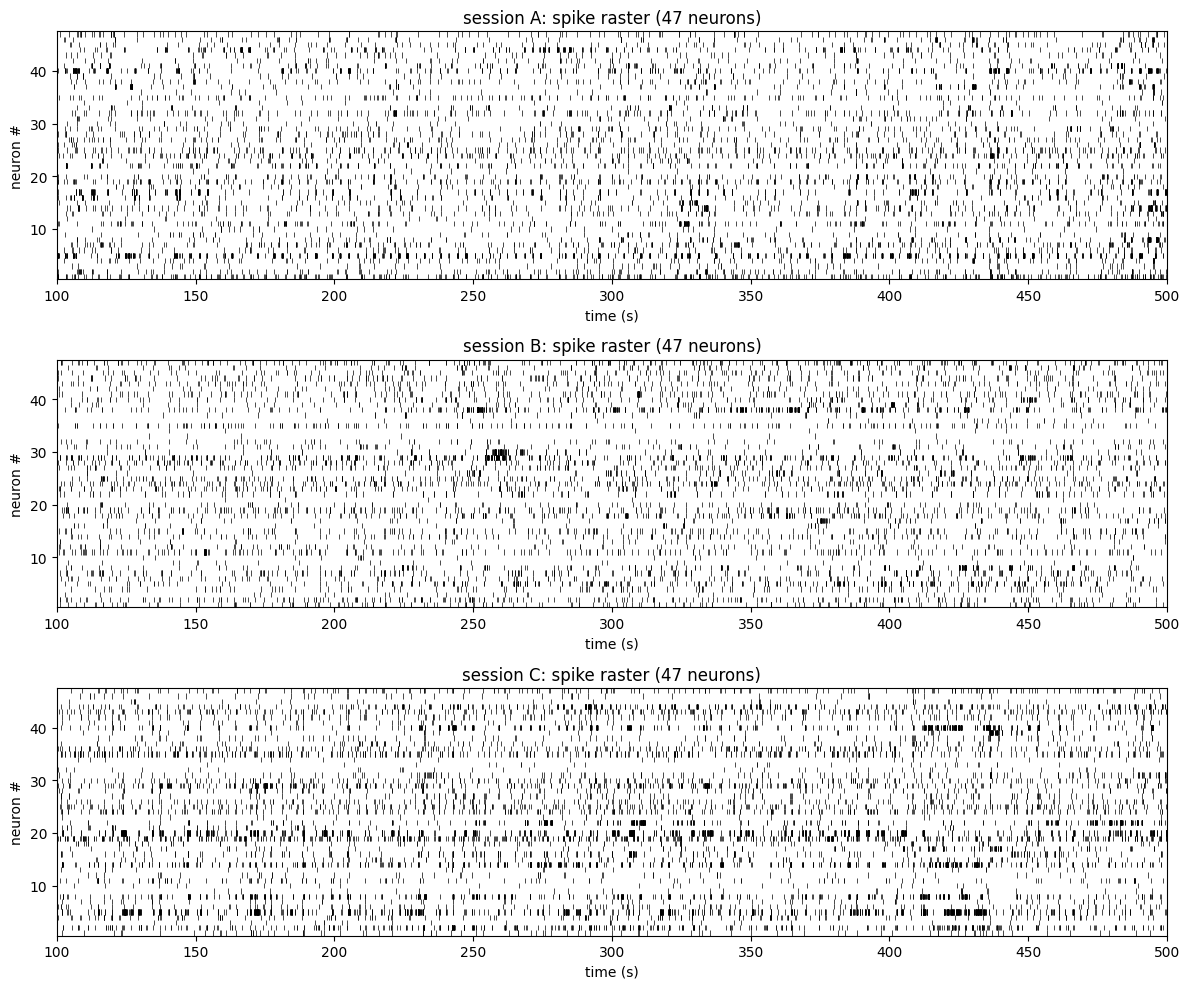

In [131]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

plot_spike_raster(data, session="A", ax=axes[0], threshold=0.02, xlim=(100, 500))
plot_spike_raster(data, session="B", ax=axes[1], threshold=0.02, xlim=(100, 500))
plot_spike_raster(data, session="C", ax=axes[2], threshold=0.02, xlim=(100, 500))

plt.tight_layout()
plt.show()

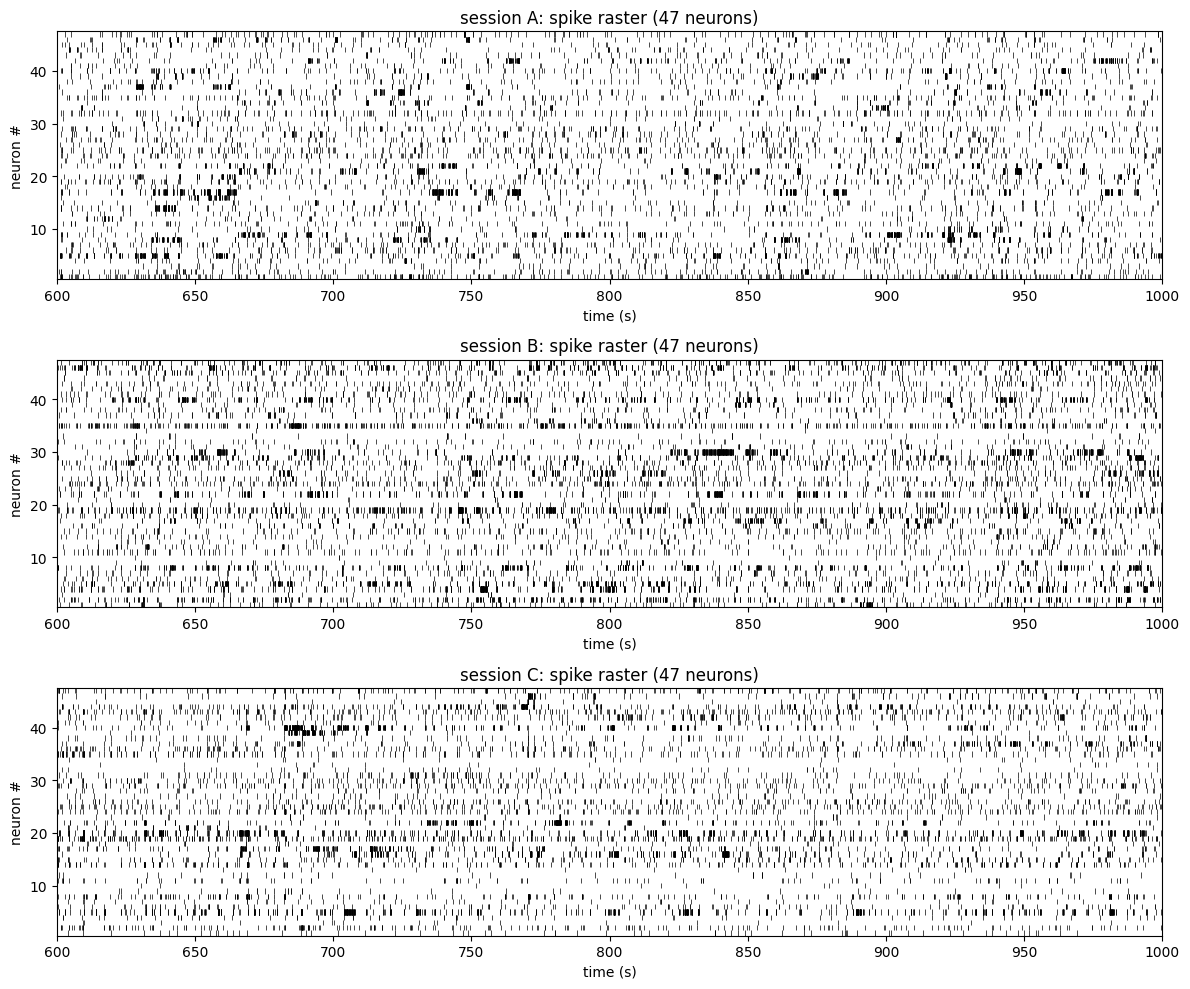

In [132]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

plot_spike_raster(data, session="A", ax=axes[0], threshold=0.02, xlim=(600, 1000))
plot_spike_raster(data, session="B", ax=axes[1], threshold=0.02, xlim=(600, 1000))
plot_spike_raster(data, session="C", ax=axes[2], threshold=0.02, xlim=(600, 1000))

plt.tight_layout()
plt.show()

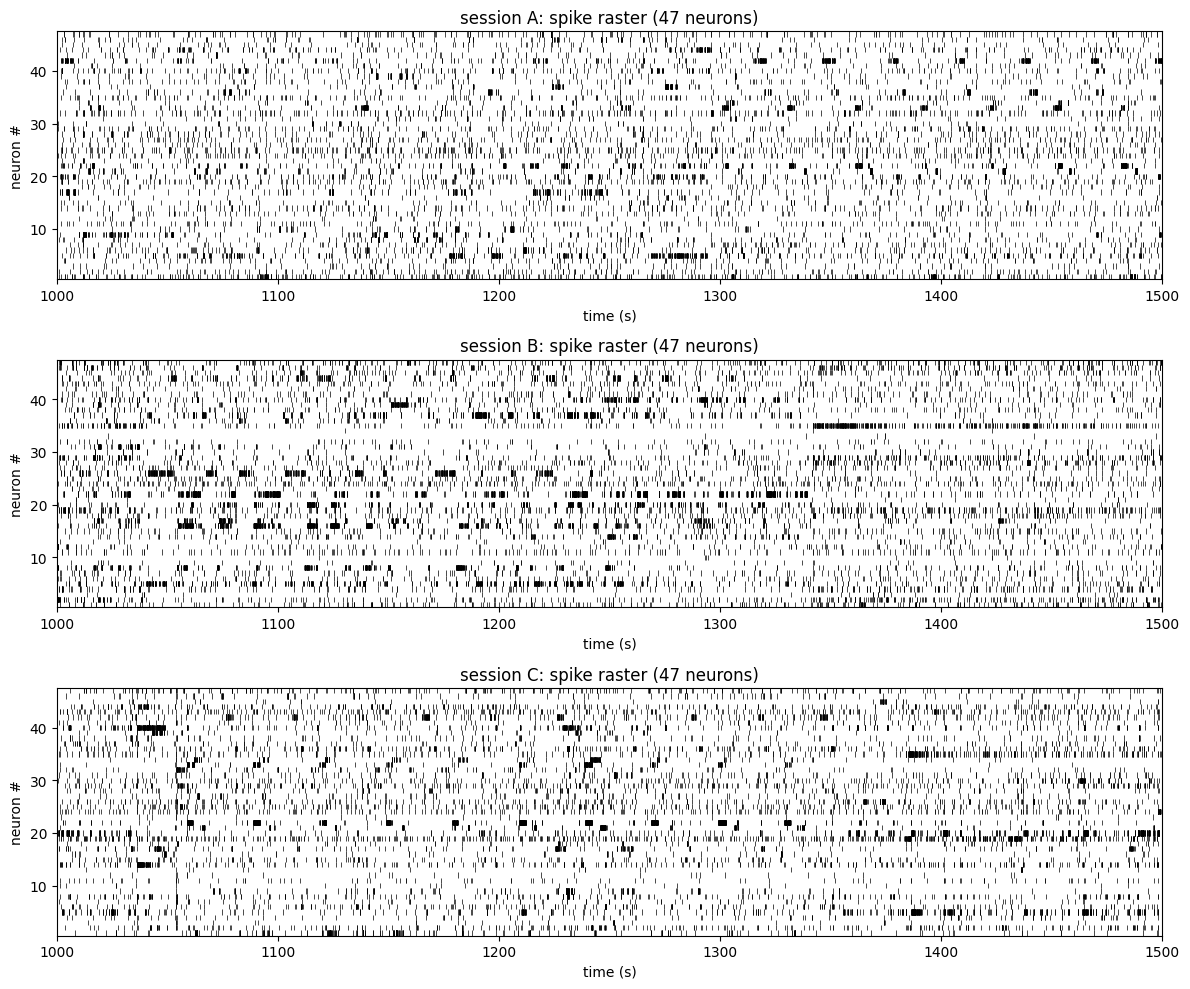

In [133]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

plot_spike_raster(data, session="A", ax=axes[0], threshold=0.02, xlim=(1000, 1500))
plot_spike_raster(data, session="B", ax=axes[1], threshold=0.02, xlim=(1000, 1500))
plot_spike_raster(data, session="C", ax=axes[2], threshold=0.02, xlim=(1000, 1500))

plt.tight_layout()
plt.show()

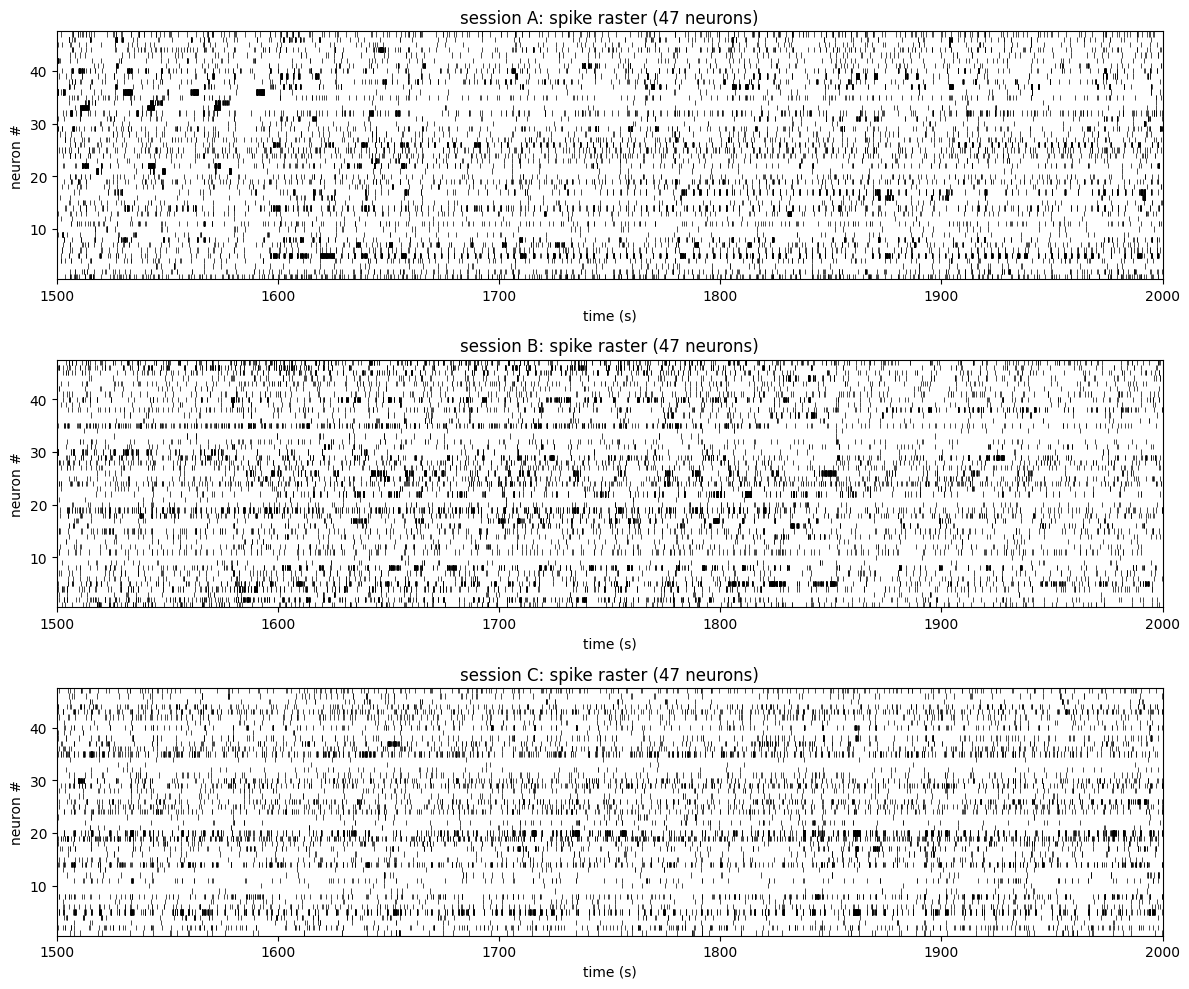

In [134]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

plot_spike_raster(data, session="A", ax=axes[0], threshold=0.02, xlim=(1500, 2000))
plot_spike_raster(data, session="B", ax=axes[1], threshold=0.02, xlim=(1500, 2000))
plot_spike_raster(data, session="C", ax=axes[2], threshold=0.02, xlim=(1500, 2000))

plt.tight_layout()
plt.show()

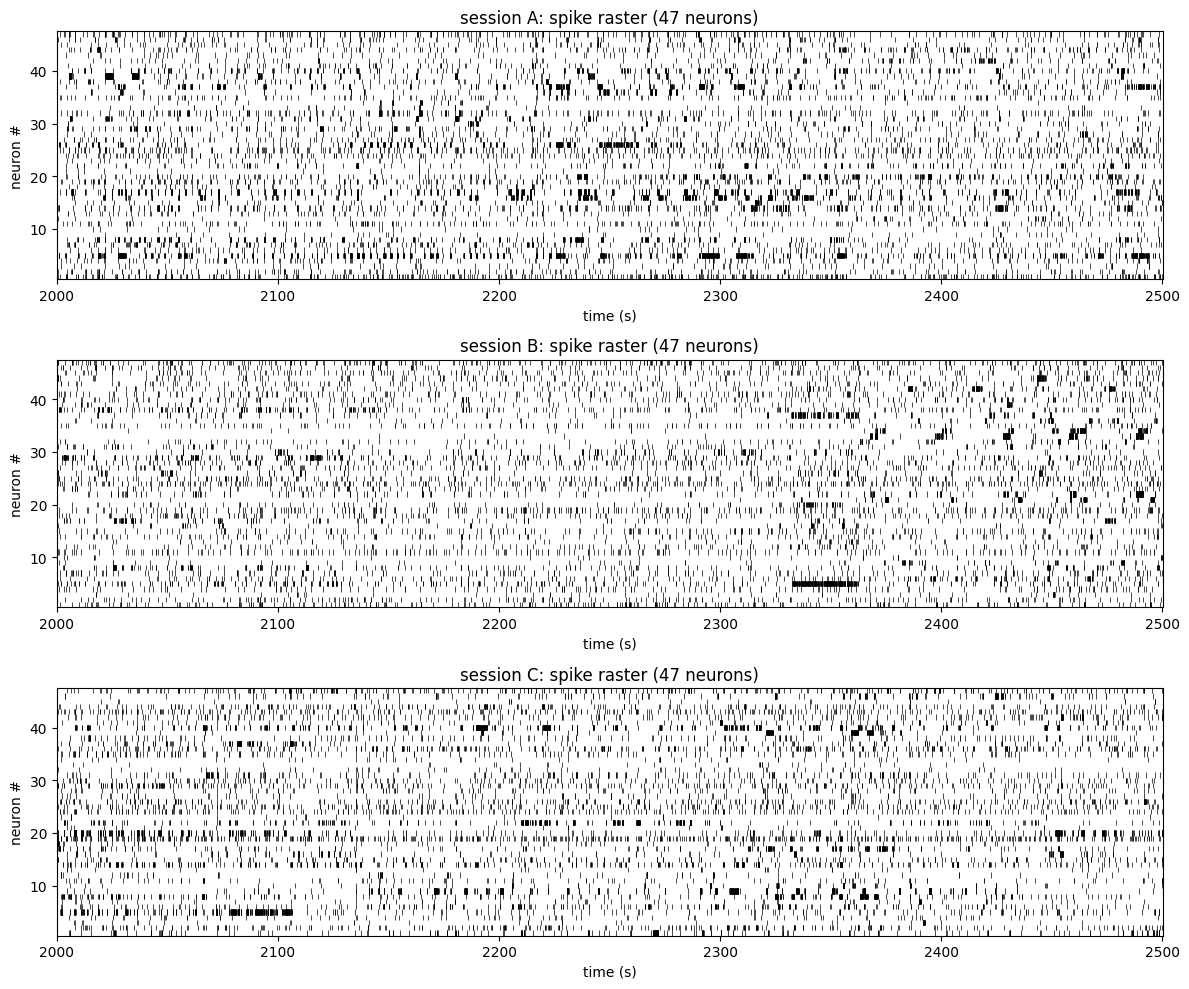

In [135]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

plot_spike_raster(data, session="A", ax=axes[0], threshold=0.02, xlim=(2000, 2500))
plot_spike_raster(data, session="B", ax=axes[1], threshold=0.02, xlim=(2000, 2500))
plot_spike_raster(data, session="C", ax=axes[2], threshold=0.02, xlim=(2000, 2500))

plt.tight_layout()
plt.show()

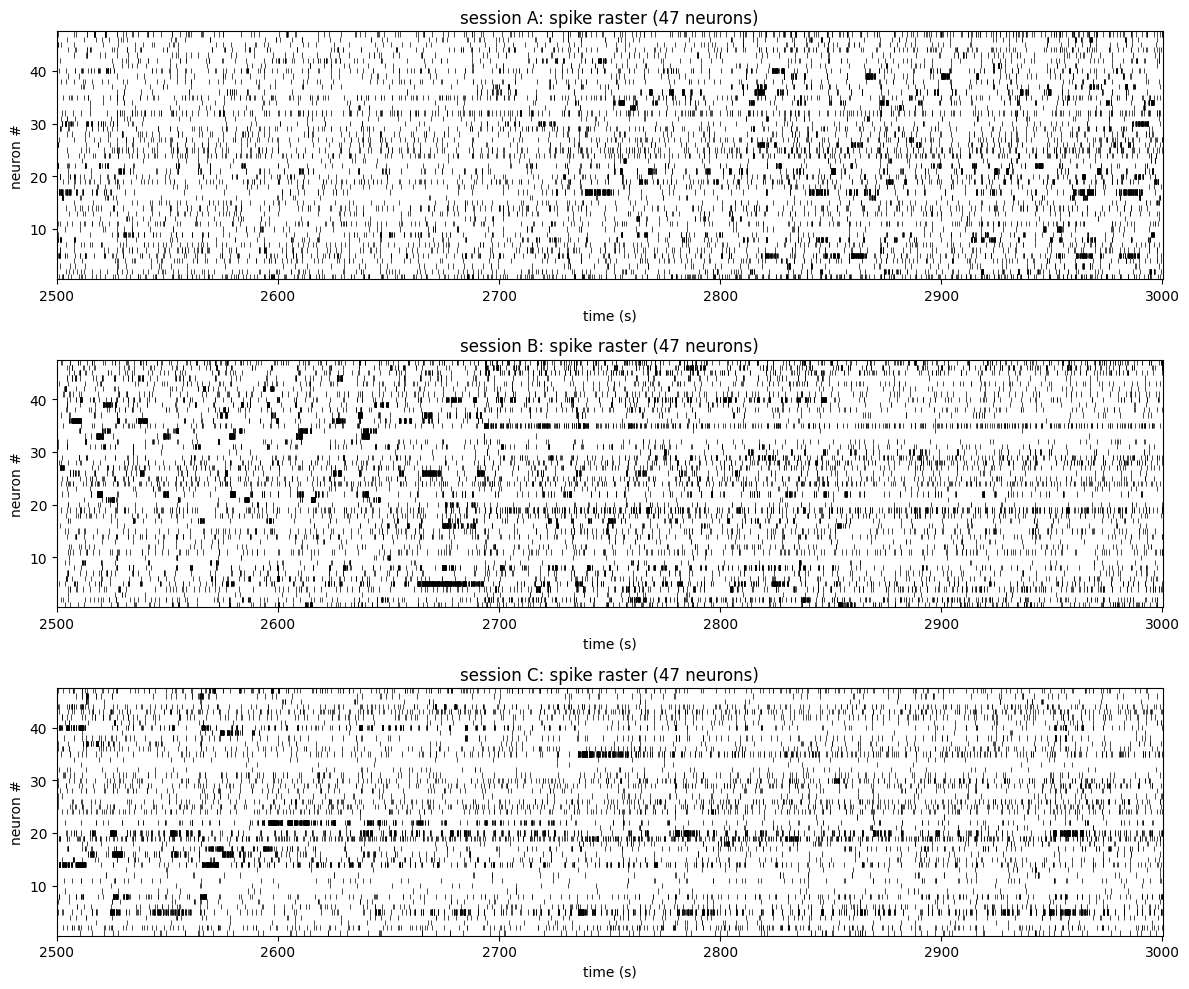

In [136]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

plot_spike_raster(data, session="A", ax=axes[0], threshold=0.02, xlim=(2500, 3000))
plot_spike_raster(data, session="B", ax=axes[1], threshold=0.02, xlim=(2500, 3000))
plot_spike_raster(data, session="C", ax=axes[2], threshold=0.02, xlim=(2500, 3000))

plt.tight_layout()
plt.show()

In [137]:
def rank_cells_by_activity(data, session, metric="sum"):
    """
    Rank all cells by their overall spike activity within a session.

    Parameters
    ----------
    metric : str
        "sum" = total spike activity across the whole session
        "mean" = average spike activity per timepoint
        "pct_active" = % of timepoints where spike activity > 0

    Returns
    -------
    pd.DataFrame, sorted from most to least active, with columns:
        cell, sum_activity, mean_activity, pct_active
    """
    spikes = data["sessions"][session]["spikes"]  # (n_cells, n_timepoints)
    n_cells = spikes.shape[0]

    rows = []
    for i in range(n_cells):
        cell_spikes = spikes[i]
        rows.append({
            "cell": i,
            "sum_activity": np.nansum(cell_spikes),
            "mean_activity": np.nanmean(cell_spikes),
            "pct_active": np.mean(cell_spikes > 0) * 100,
        })

    df = pd.DataFrame(rows)
    df = df.sort_values(metric, ascending=False).reset_index(drop=True)
    return df

In [ ]:
cell_ranking = rank_cells_by_activity(data, session="A", metric="sum_activity")
print(cell_ranking.head(10))  # top 10 active cells

   cell  sum_activity  mean_activity  pct_active
0     4   2008.821045       0.017397    8.708680
1    21    957.493408       0.008292    4.723264
2    36    946.992981       0.008201    4.521482
3    16    706.073914       0.006115    5.616129
4     7    478.725220       0.004146    5.520867
5    15    408.700958       0.003539    4.204519
6    19    387.067108       0.003352    5.216028
7    25    369.594147       0.003201    5.513939
8    43    347.863586       0.003013    5.218626
9    39    339.924683       0.002944    6.041344


## Compare the top 10 active neurons respond to different category

## Top 10 Active Cells — Definition

For each session, spike activity (`spikes`, from OASIS deconvolution)
is summed across all timepoints for each of the 47 matched cells:

sum_activity[i] = sum(spikes[i, :])

Cells are ranked in descending order of this total, and the top 10
are selected as the "most active" cells for that session.

**Note**: This reflects overall activity level, not stimulus-specific
selectivity. Rankings may differ between sessions since the same cell
can be more or less active depending on the stimulus shown.

In [140]:
def compare_top_cells_by_category(data, session, stim_name, frame_to_category, top_cells):
    """
    Compare aversive vs neutral activity, but only using the most active cells,
    instead of averaging across all 47 cells (which may dilute the signal).
    """
    s = data["sessions"][session]
    spikes = s["spikes"][top_cells, :]  # only keep the selected active cells
    stim_table = s["stim_tables"][stim_name].copy()
    stim_table = stim_table[stim_table["frame"] != -1].reset_index(drop=True)

    sum_spikes = []
    for _, row in stim_table.iterrows():
        start, end = int(row["start"]), int(row["end"])
        sum_spikes.append(np.nansum(spikes[:, start:end + 1]))

    stim_table["sum_spikes"] = sum_spikes
    stim_table["category"] = stim_table["frame"].map(frame_to_category)
    return stim_table

top_10_cells = cell_ranking.head(10)["cell"].values
df_top = compare_top_cells_by_category(data, session="B", stim_name="natural_scenes",
                                         frame_to_category=frame_to_category,
                                         top_cells=top_10_cells)
print(df_top.groupby("category")["sum_spikes"].describe())

           count      mean       std  min       25%       50%       75%  \
category                                                                  
aversive  1850.0  0.445118  0.816929  0.0  0.015336  0.084049  0.518867   
neutral   4050.0  0.447362  0.848783  0.0  0.014023  0.074228  0.493248   

               max  
category            
aversive  7.511192  
neutral   8.406283  


In [141]:
def get_top_cell_activity_by_stimulus(data, top_cells, stimulus_session_map=STIMULUS_SESSION_MAP):
    """
    Compare total spike activity across the four stimulus types,
    using only the most active cells (instead of averaging across all 47).

    Returns
    -------
    dict: {stimulus_name: np.ndarray of per-trial summed spike values, top cells only}
    """
    stimulus_activity = {}

    for stim_name, session in stimulus_session_map.items():
        s = data["sessions"][session]
        spikes = s["spikes"][top_cells, :]  # only keep the selected active cells
        stim_table = s["stim_tables"][stim_name]

        starts = stim_table["start"].astype(int).values
        ends = stim_table["end"].astype(int).values

        trial_sums = [np.nansum(spikes[:, start:end + 1]) for start, end in zip(starts, ends)]
        stimulus_activity[stim_name] = np.array(trial_sums)

    return stimulus_activity

/var/folders/42/yzjg5hd11vv65hsck7wh0lb00000gn/T/ipykernel_10599/931326212.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_long, x="stimulus", y="sum_spikes", ax=ax,


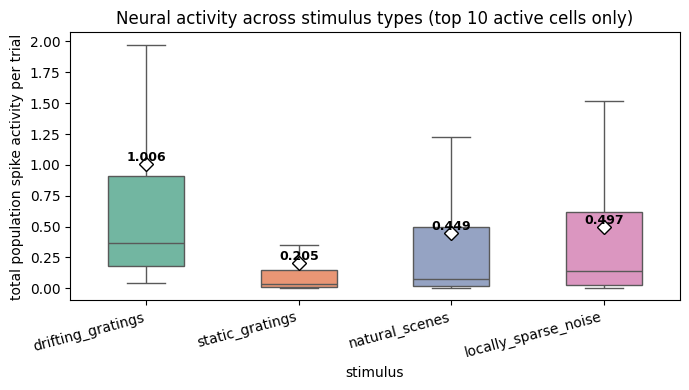

In [142]:
top_10_cells = cell_ranking.head(10)["cell"].values

stimulus_activity_top = get_top_cell_activity_by_stimulus(data, top_cells=top_10_cells)

fig, ax = plt.subplots(figsize=(7, 4))
plot_activity_by_stimulus(stimulus_activity_top, ax=ax)
ax.set_title("Neural activity across stimulus types (top 10 active cells only)")
plt.tight_layout()
plt.show()

In [143]:
def get_top_cells_per_session(data, sessions=["A", "B", "C"], top_n=10):
    """
    Rank cells by activity separately within each session,
    and return the top N most active cell indices for each.
    """
    top_cells_by_session = {}
    for session in sessions:
        ranking = rank_cells_by_activity(data, session=session, metric="sum_activity")
        top_cells_by_session[session] = ranking.head(top_n)["cell"].values
    return top_cells_by_session


def get_activity_by_stimulus_own_ranking(data, stimulus_session_map, top_cells_by_session):
    """
    Compare total spike activity across stimulus types, but use each
    stimulus's own session-specific top active cells (instead of one
    fixed set of cells from a single session).
    """
    stimulus_activity = {}

    for stim_name, session in stimulus_session_map.items():
        s = data["sessions"][session]
        top_cells = top_cells_by_session[session]  # session-specific ranking
        spikes = s["spikes"][top_cells, :]
        stim_table = s["stim_tables"][stim_name]

        starts = stim_table["start"].astype(int).values
        ends = stim_table["end"].astype(int).values

        trial_sums = [np.nansum(spikes[:, start:end + 1]) for start, end in zip(starts, ends)]
        stimulus_activity[stim_name] = np.array(trial_sums)

    return stimulus_activity

Session A top cells: [np.int64(4), np.int64(7), np.int64(15), np.int64(16), np.int64(19), np.int64(21), np.int64(25), np.int64(36), np.int64(39), np.int64(43)]
Session B top cells: [np.int64(4), np.int64(7), np.int64(18), np.int64(21), np.int64(25), np.int64(28), np.int64(34), np.int64(36), np.int64(39), np.int64(45)]
Session C top cells: [np.int64(4), np.int64(7), np.int64(13), np.int64(16), np.int64(18), np.int64(19), np.int64(21), np.int64(34), np.int64(39), np.int64(43)]


/var/folders/42/yzjg5hd11vv65hsck7wh0lb00000gn/T/ipykernel_10599/931326212.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_long, x="stimulus", y="sum_spikes", ax=ax,


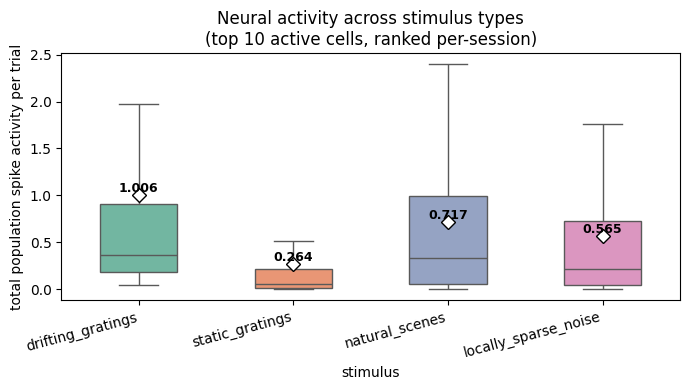

In [144]:
top_cells_by_session = get_top_cells_per_session(data, top_n=10)

# Check overlap between sessions' top cells (interesting to see if same cells are consistently active)
print("Session A top cells:", sorted(top_cells_by_session["A"]))
print("Session B top cells:", sorted(top_cells_by_session["B"]))
print("Session C top cells:", sorted(top_cells_by_session["C"]))

stimulus_activity_own = get_activity_by_stimulus_own_ranking(
    data, STIMULUS_SESSION_MAP, top_cells_by_session
)

fig, ax = plt.subplots(figsize=(7, 4))
plot_activity_by_stimulus(stimulus_activity_own, ax=ax)
ax.set_title("Neural activity across stimulus types\n(top 10 active cells, ranked per-session)")
plt.tight_layout()
plt.show()
